# TP 1 - Clinic - Exploratory Data Analysis (EDA)

### Setup et imports

In [1]:
import sys
from pathlib import Path

# Racine du projet = dossier parent du dossier notebooks/
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

from config.paths import DATA_DIR
from config.files import FILES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

from src.io import read_csv_safe
from src.profiling import basic_profile, build_data_dictionary, plot_histogram
from src.casting import to_int, to_bool, to_float, to_date

PROJECT_ROOT: C:\Users\Thib\Documents\EPSI\data_warehouse\tp\tp_hospital


### Chargement des CSV

In [2]:
dfs_raw = {}

for name, filename in FILES.items():
    path = DATA_DIR / filename
    dfs_raw[name] = read_csv_safe(path)
    print(f"{name}: loaded {dfs_raw[name].shape} from {path}")

list(dfs_raw.keys())

patients: loaded (1000, 12) from C:\Users\Thib\Documents\EPSI\data_warehouse\tp\tp_hospital\data\patients.csv
staff: loaded (58, 3) from C:\Users\Thib\Documents\EPSI\data_warehouse\tp\tp_hospital\data\staff.csv
staff_schedule: loaded (3016, 3) from C:\Users\Thib\Documents\EPSI\data_warehouse\tp\tp_hospital\data\staff_schedule.csv
admissions_requests: loaded (1148, 5) from C:\Users\Thib\Documents\EPSI\data_warehouse\tp\tp_hospital\data\admissions_requests.csv


['patients', 'staff', 'staff_schedule', 'admissions_requests']

### Profiling brut

In [3]:
for name, df in dfs_raw.items():
    basic_profile(df, name=name)

DATASET: patients
--------------------------------------------------------------------------------
Shape: 1000 lignes x 12 colonnes

Aperçu:


,patient_id,name,age,arrival_yearweek,departure_yearweek,arrival_date,departure_date,service,satisfaction,los,weeks_active,request_id
0,PAT-82531806,Tom Lohne,90,202511,202512,15/03/2025,21/03/2025,ICU,"56,9",7,"[202511, 202512]",RQ-207
1,PAT-4583c07a,David Davis,55,202519,202520,11/05/2025,17/05/2025,general_medicine,"74,8",7,"[202519, 202520]",RQ-380
2,PAT-965208ae,Gold Roger,89,202535,202536,30/08/2025,03/09/2025,general_medicine,"68,6",5,"[202535, 202536]",RQ-746
3,PAT-c3770ed2,Elizabeth Mendez,32,202536,202537,05/09/2025,09/09/2025,general_medicine,"81,4",5,"[202536, 202537]",RQ-769
4,PAT-17ceaafc,Roxy Ragej,71,202514,202515,05/04/2025,09/04/2025,general_medicine,"75,9",5,"[202514, 202515]",RQ-277



Types (pandas dtypes):


,dtype
patient_id,object
name,object
age,object
arrival_yearweek,object
departure_yearweek,object
arrival_date,object
departure_date,object
service,object
satisfaction,object
los,object



Valeurs manquantes (top 20):


...


Types (pandas dtypes):


,dtype
request_id,object
yearweek,object
service,object
accepted,object
reason,object



Valeurs manquantes (top 20):


,missing_count
reason,1000
request_id,0
yearweek,0
service,0
accepted,0



Statistiques (numériques si déjà castés):
Aucune colonne numérique castée pour l'instant.

Valeurs distinctes (colonnes catégorielles - top 10):
- request_id: 1148 valeurs distinctes
- yearweek: 53 valeurs distinctes
- service: 4 valeurs distinctes
- accepted: 2 valeurs distinctes
- reason: 1 valeurs distinctes



### Fonctions de casting

In [4]:
from src.domain_casting import (
    cast_patients,
    cast_staff,
    cast_staff_schedule,
    cast_admissions_requests,
)

### Appliquer casting + profiler après casting

In [5]:
dfs = {}
dfs["patients"] = cast_patients(dfs_raw["patients"])
dfs["staff"] = cast_staff(dfs_raw["staff"])
dfs["staff_schedule"] = cast_staff_schedule(dfs_raw["staff_schedule"])
dfs["admissions_requests"] = cast_admissions_requests(dfs_raw["admissions_requests"])

for name, df in dfs.items():
    basic_profile(df, name=f"{name} (casted)")

DATASET: patients (casted)
--------------------------------------------------------------------------------
Shape: 1000 lignes x 12 colonnes

Aperçu:


,patient_id,name,age,arrival_yearweek,departure_yearweek,arrival_date,departure_date,service,satisfaction,los,weeks_active,request_id
0,PAT-82531806,Tom Lohne,90,202511,202512,2025-03-15,2025-03-21,icu,56.9,7,"[202511, 202512]",RQ-207
1,PAT-4583c07a,David Davis,55,202519,202520,2025-05-11,2025-05-17,general_medicine,74.8,7,"[202519, 202520]",RQ-380
2,PAT-965208ae,Gold Roger,89,202535,202536,2025-08-30,2025-09-03,general_medicine,68.6,5,"[202535, 202536]",RQ-746
3,PAT-c3770ed2,Elizabeth Mendez,32,202536,202537,2025-09-05,2025-09-09,general_medicine,81.4,5,"[202536, 202537]",RQ-769
4,PAT-17ceaafc,Roxy Ragej,71,202514,202515,2025-04-05,2025-04-09,general_medicine,75.9,5,"[202514, 202515]",RQ-277



Types (pandas dtypes):


,dtype
patient_id,object
name,object
age,Int64
arrival_yearweek,Int64
departure_yearweek,Int64
arrival_date,object
departure_date,object
service,object
satisfaction,Float64
los,Int64



Valeurs manquantes (top 20):


...


Valeurs manquantes (top 20):


,missing_count
reason,1000
request_id,0
yearweek,0
service,0
accepted,0



Statistiques (numériques si déjà castés):


,count,mean,std,min,25%,50%,75%,max
yearweek,1148.0,202527.731707,16.774087,202501.0,202514.0,202527.5,202540.0,202601.0



Valeurs distinctes (colonnes catégorielles - top 10):
- request_id: 1148 valeurs distinctes
- service: 4 valeurs distinctes
- accepted: 2 valeurs distinctes
- reason: 1 valeurs distinctes



### Vérif rapide dates / cohérences simples

In [6]:
patients = dfs["patients"]

# arrival_date <= departure_date
bad_dates = patients.dropna(subset=["arrival_date", "departure_date"])
bad_dates = bad_dates[bad_dates["arrival_date"] > bad_dates["departure_date"]]
print("Bad arrival/departure date rows:", len(bad_dates))
display(bad_dates.head(10))

# arrival_yearweek <= departure_yearweek
bad_yw = patients.dropna(subset=["arrival_yearweek", "departure_yearweek"])
bad_yw = bad_yw[bad_yw["arrival_yearweek"] > bad_yw["departure_yearweek"]]
print("Bad arrival/departure yearweek rows:", len(bad_yw))
display(bad_yw.head(10))

Bad arrival/departure date rows: 0


,patient_id,name,age,arrival_yearweek,departure_yearweek,arrival_date,departure_date,service,satisfaction,los,weeks_active,request_id


Bad arrival/departure yearweek rows: 0


,patient_id,name,age,arrival_yearweek,departure_yearweek,arrival_date,departure_date,service,satisfaction,los,weeks_active,request_id


### Vérifier cohérence accepted / reason

In [7]:
ar = dfs["admissions_requests"]

# accepted == True => reason devrait être null
accepted_with_reason = ar[(ar["accepted"] == True) & (ar["reason"].notna())]
print("Accepted but has reason:", len(accepted_with_reason))
display(accepted_with_reason.head(10))

# accepted == False => reason devrait être non null (souvent)
refused_no_reason = ar[(ar["accepted"] == False) & (ar["reason"].isna())]
print("Refused but no reason:", len(refused_no_reason))
display(refused_no_reason.head(10))

print("Reasons:", ar["reason"].value_counts(dropna=False).head(10))

Accepted but has reason: 0


,request_id,yearweek,service,accepted,reason


Refused but no reason: 0


,request_id,yearweek,service,accepted,reason


Reasons: reason
<NA>      1000
no_bed     148
Name: count, dtype: Int64


### Relations potentielles (PK / FK)

In [8]:
# patients.request_id -> admissions_requests.request_id
patients_req = set(dfs["patients"]["request_id"].dropna().unique())
ar_req = set(dfs["admissions_requests"]["request_id"].dropna().unique())

missing_in_ar = sorted(list(patients_req - ar_req))[:20]
missing_in_patients = sorted(list(ar_req - patients_req))[:20]

print("patients.request_id not found in admissions_requests:", len(patients_req - ar_req))
print("Sample:", missing_in_ar)

print("admissions_requests.request_id not found in patients:", len(ar_req - patients_req))
print("Sample:", missing_in_patients)

patients.request_id not found in admissions_requests: 0
Sample: []
admissions_requests.request_id not found in patients: 148
Sample: ['RQ-1009', 'RQ-1010', 'RQ-1017', 'RQ-1022', 'RQ-103', 'RQ-1034', 'RQ-1041', 'RQ-1054', 'RQ-1060', 'RQ-1067', 'RQ-1074', 'RQ-1080', 'RQ-1084', 'RQ-109', 'RQ-1094', 'RQ-1111', 'RQ-1116', 'RQ-1121', 'RQ-1130', 'RQ-1148']


### Relations staff_schedule ↔ staff (nom)

In [9]:
staff_names = set(dfs["staff"]["staff_name"].dropna().unique())
sched_names = set(dfs["staff_schedule"]["staff_name"].dropna().unique())

missing_in_staff = sorted(list(sched_names - staff_names))[:20]
print("staff_schedule names not found in staff:", len(sched_names - staff_names))
print("Sample:", missing_in_staff)

staff_schedule names not found in staff: 0
Sample: []


### Déterminer le grain naturel (avec vérifs d’unicité)

In [10]:
def check_grain(df: pd.DataFrame, keys: list[str], name: str):
    dup = df.duplicated(subset=keys, keep=False)
    ndup = int(dup.sum())
    print(f"{name} grain check on {keys}: duplicated rows = {ndup}")
    if ndup:
        display(df.loc[dup, keys].head(10))

check_grain(dfs["patients"], ["patient_id"], "patients")
check_grain(dfs["admissions_requests"], ["request_id"], "admissions_requests")
check_grain(dfs["staff_schedule"], ["yearweek", "staff_name"], "staff_schedule")
check_grain(dfs["staff"], ["staff_name", "role", "service"], "staff")

patients grain check on ['patient_id']: duplicated rows = 0
admissions_requests grain check on ['request_id']: duplicated rows = 0
staff_schedule grain check on ['yearweek', 'staff_name']: duplicated rows = 0
staff grain check on ['staff_name', 'role', 'service']: duplicated rows = 0


- patients : grain = 1 ligne / patient_id (≈ séjour)
- admissions_requests : grain = 1 ligne / request_id (demande)
- staff_schedule : grain = 1 ligne / semaine / personne
- staff : grain = référentiel par personne (mais possible multi-lignes si une personne a plusieurs rôles/services)

### Distributions simples (age, satisfaction, los)

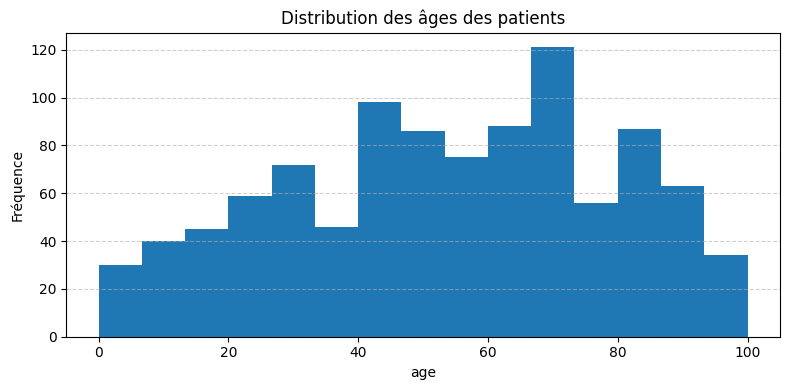

age -> min=0 | max=100 | mean=53.54


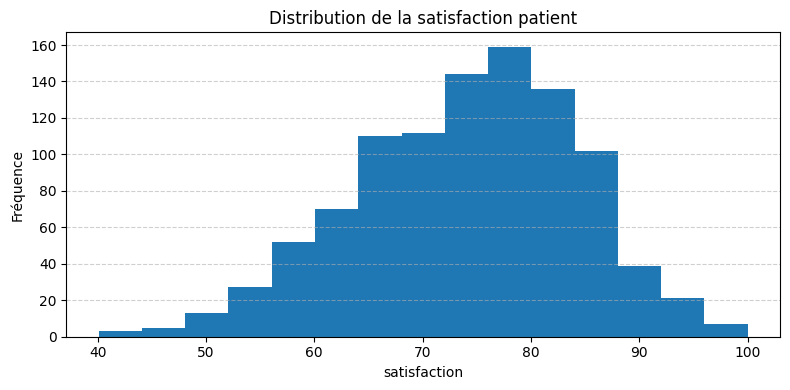

satisfaction -> min=40.1 | max=100.0 | mean=74.11


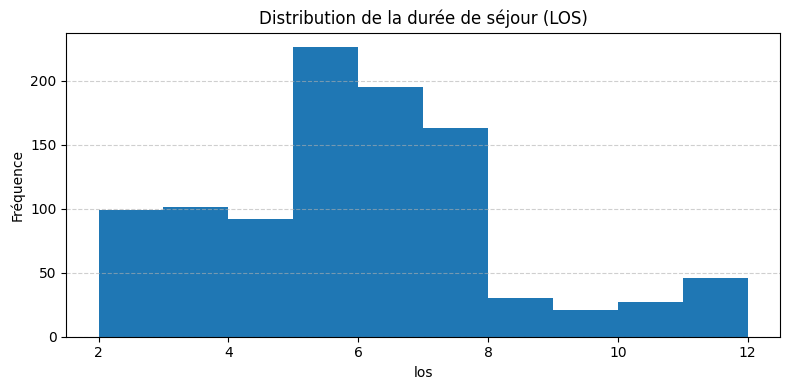

los -> min=2 | max=12 | mean=5.54
Services distribution:


service
general_medicine    400
surgery             250
emergency           200
icu                 150
Name: count, dtype: int64

In [12]:
patients = dfs["patients"]

plot_histogram(patients["age"], "Distribution des âges des patients", bins=15)
plot_histogram(patients["satisfaction"], "Distribution de la satisfaction patient", bins=15)
plot_histogram(patients["los"], "Distribution de la durée de séjour (LOS)", bins=10)

print("Services distribution:")
display(patients["service"].value_counts(dropna=False))

### Dictionnaire de données (synthétique)

In [14]:
definitions_patients = {
    "patient_id": "Identifiant unique du patient/séjour.",
    "name": "Prénom Nom du patient.",
    "age": "Âge du patient.",
    "arrival_yearweek": "Semaine ISO de l'arrivée (YYYYWW).",
    "departure_yearweek": "Semaine ISO de sortie (YYYYWW).",
    "arrival_date": "Date d'arrivée (dd/mm/yyyy).",
    "departure_date": "Date de sortie (dd/mm/yyyy).",
    "service": "Service hospitalier.",
    "satisfaction": "Score de satisfaction patient.",
    "los": "Length of stay (jours).",
    "weeks_active": "Liste de semaines.",
    "request_id": "Identifiant de la demande d'admission associée.",
}

selected_patients = ["patient_id","name","age","arrival_yearweek","departure_yearweek","arrival_date","departure_date","service","satisfaction","los","weeks_active","request_id"]
dd_patients = build_data_dictionary(dfs["patients"], selected_patients, definitions_patients)
display(dd_patients)

,column,dtype,definition,example,missing_count,distinct_count
0,patient_id,object,Identifiant unique du patient/séjour.,PAT-82531806,0,1000
1,name,object,Prénom Nom du patient.,Tom Lohne,0,1000
2,age,Int64,Âge du patient.,90,0,101
3,arrival_yearweek,Int64,Semaine ISO de l'arrivée (YYYYWW).,202511,0,53
4,departure_yearweek,Int64,Semaine ISO de sortie (YYYYWW).,202512,0,53
5,arrival_date,object,Date d'arrivée (dd/mm/yyyy).,2025-03-15,0,351
6,departure_date,object,Date de sortie (dd/mm/yyyy).,2025-03-21,0,347
7,service,object,Service hospitalier.,icu,0,4
8,satisfaction,Float64,Score de satisfaction patient.,56.9,0,382
9,los,Int64,Length of stay (jours).,7,0,11


In [15]:
definitions_staff = {
    "staff_name": "Nom complet du membre du personnel.",
    "role": "Fonction exercée (doctor, nurse).",
    "service": "Service hospitalier d'affectation du personnel.",
}

selected_staff = ["staff_name", "role", "service"]
dd_staff = build_data_dictionary(dfs["staff"], selected_staff, definitions_staff)
display(dd_staff)

,column,dtype,definition,example,missing_count,distinct_count
0,staff_name,object,Nom complet du membre du personnel.,Noah Rhodes,0,58
1,role,object,"Fonction exercée (doctor, nurse).",doctor,0,3
2,service,object,Service hospitalier d'affectation du personnel.,emergency,0,4


In [16]:
definitions_staff_schedule = {
    "yearweek": "Semaine ISO au format YYYYWW.",
    "staff_name": "Nom du membre du personnel.",
    "present": "Indique si le membre du personnel est présent cette semaine (True/False).",
}

selected_staff_schedule = ["yearweek", "staff_name", "present"]
dd_staff_schedule = build_data_dictionary(dfs["staff_schedule"], selected_staff_schedule, definitions_staff_schedule)
display(dd_staff_schedule)

,column,dtype,definition,example,missing_count,distinct_count
0,yearweek,Int64,Semaine ISO au format YYYYWW.,202501,0,52
1,staff_name,object,Nom du membre du personnel.,Abigail Shaffer,0,58
2,present,boolean,Indique si le membre du personnel est présent ...,True,0,2


In [17]:
definitions_admissions_requests = {
    "request_id": "Identifiant unique de la demande d'admission.",
    "yearweek": "Semaine ISO de la demande (format YYYYWW).",
    "service": "Service hospitalier concerné par la demande.",
    "accepted": "Indique si la demande a été acceptée (True/False).",
    "reason": "Motif du refus si la demande n'a pas été acceptée (ex: no_bed).",
}

selected_admissions_requests = ["request_id", "yearweek", "service", "accepted", "reason"]
dd_admissions_requests = build_data_dictionary(dfs["admissions_requests"], selected_admissions_requests, definitions_admissions_requests)
display(dd_admissions_requests)

,column,dtype,definition,example,missing_count,distinct_count
0,request_id,object,Identifiant unique de la demande d'admission.,RQ-1,0,1148
1,yearweek,Int64,Semaine ISO de la demande (format YYYYWW).,202501,0,53
2,service,object,Service hospitalier concerné par la demande.,icu,0,4
3,accepted,boolean,Indique si la demande a été acceptée (True/Fal...,True,0,2
4,reason,string,Motif du refus si la demande n'a pas été accep...,no_bed,1000,1


In [18]:
full_data_dictionary = pd.concat([
    dd_patients.assign(dataset="patients"),
    dd_staff.assign(dataset="staff"),
    dd_staff_schedule.assign(dataset="staff_schedule"),
    dd_admissions_requests.assign(dataset="admissions_requests"),
], ignore_index=True)

display(full_data_dictionary)

,column,dtype,definition,example,missing_count,distinct_count,dataset
0,patient_id,object,Identifiant unique du patient/séjour.,PAT-82531806,0,1000,patients
1,name,object,Prénom Nom du patient.,Tom Lohne,0,1000,patients
2,age,Int64,Âge du patient.,90,0,101,patients
3,arrival_yearweek,Int64,Semaine ISO de l'arrivée (YYYYWW).,202511,0,53,patients
4,departure_yearweek,Int64,Semaine ISO de sortie (YYYYWW).,202512,0,53,patients
5,arrival_date,object,Date d'arrivée (dd/mm/yyyy).,2025-03-15,0,351,patients
6,departure_date,object,Date de sortie (dd/mm/yyyy).,2025-03-21,0,347,patients
7,service,object,Service hospitalier.,icu,0,4,patients
8,satisfaction,Float64,Score de satisfaction patient.,56.9,0,382,patients
9,los,Int64,Length of stay (jours).,7,0,11,patients
